# 06 — XGBoost Model Training (PV1)

**Goal:** train and evaluate an XGBoost model predicting `PV1_Power_W` from weather and time features.

**Input:** `../Output/checkpoint_05_final.pkl`


In [1]:
TARGET = "PV1_Power_W"

## Setup

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

OUTPUT_DIR = "../Output"
df = pd.read_pickle(f"{OUTPUT_DIR}/checkpoint_05_final.pkl")
df = df.sort_values("Timestamp").reset_index(drop=True)
print(df.shape)


(5832, 30)


## 1. Build a leakage-free feature set

All electrical readings are excluded from the features — current, voltage, and power for both
panels, plus the combined total. These are outputs measured at the same instant as power
itself, not things you'd know in advance in a real forecasting scenario.

Redundant weather columns from the correlation analysis are also dropped
(`UV_Index` ≈ `Solar_Radiation_Wm2`, indoor sensors ≈ outdoor equivalents, `AQI_US`/`PM10`/`PM1`
≈ `PM25`, `Wind_Gust_ms` ≈ `Wind_Speed_ms`).


In [16]:
electrical_cols = ["PV1_Power_W", "PV2_Power_W", "PV_Total_Power_W",
                   "PV1_Current_A", "PV2_Current_A", "PV1_Voltage_V", "PV2_Voltage_V"]

redundant_cols = ["UV_Index", "Indoor_Temp_C", "Indoor_Humidity_pct", "Indoor_Pressure_Pa",
                  "AQI_US", 'Pressure_hPa', "PM1_ugm3", "Wind_Gust_ms"]

drop_cols = electrical_cols + redundant_cols + ["Timestamp", "hour", "month", "PV_imputed", "is_daylight", "day_of_year"]
feature_cols = [c for c in df.columns if c not in drop_cols]

"""df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)"""

feature_cols = [c for c in feature_cols] 

print(f"Target: {TARGET}")
print(f"Feature count: {len(feature_cols)}")
print(feature_cols)


Target: PV1_Power_W
Feature count: 9
['Solar_Radiation_Wm2', 'Outdoor_Temp_C', 'Dew_Point_C', 'Wind_Speed_ms', 'Wind_Dir_deg', 'Humidity_pct', 'Rain_mm', 'PM25_ugm3', 'PM10_ugm3']


## 2. Chronological train/test split

Held-out period is the most recent ~20% of the timeline — not a random split, since adjacent
hours are correlated and a random shuffle would overstate accuracy.

In [17]:
split_date = df["Timestamp"].quantile(0.8)
train_df = df[df["Timestamp"] < split_date]
test_df = df[df["Timestamp"] >= split_date]

print(f"Train: {train_df['Timestamp'].min()} to {train_df['Timestamp'].max()}  ({len(train_df)} rows)")
print(f"Test:  {test_df['Timestamp'].min()} to {test_df['Timestamp'].max()}  ({len(test_df)} rows)")

X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_test, y_test = test_df[feature_cols], test_df[TARGET]


Train: 2026-01-01 00:00:00 to 2026-07-14 08:00:00  (4665 rows)
Test:  2026-07-14 09:00:00 to 2026-08-31 23:00:00  (1167 rows)


## 3. Train the XGBoost model

In [18]:
xgb_params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

model = XGBRegressor(**xgb_params)
model.fit(X_train, y_train)

pred = np.clip(model.predict(X_test), 0, None)


## 4. Evaluate — full test set vs. daylight-only

In [23]:
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)
print(f"[{TARGET}] Full test set   — MAE: {mae:.2f}  RMSE: {rmse:.2f}  R2: {r2:.4f}")

"""daylight_mask = test_df["is_daylight"] == 1
mae_d = mean_absolute_error(y_test[daylight_mask], pred[daylight_mask.values])
rmse_d = np.sqrt(mean_squared_error(y_test[daylight_mask], pred[daylight_mask.values]))
r2_d = r2_score(y_test[daylight_mask], pred[daylight_mask.values])
print(f"[{TARGET}] Daylight only    — MAE: {mae_d:.2f}  RMSE: {rmse_d:.2f}  R2: {r2_d:.4f}")"""


[PV1_Power_W] Full test set   — MAE: 18.94  RMSE: 33.63  R2: 0.9313


'daylight_mask = test_df["is_daylight"] == 1\nmae_d = mean_absolute_error(y_test[daylight_mask], pred[daylight_mask.values])\nrmse_d = np.sqrt(mean_squared_error(y_test[daylight_mask], pred[daylight_mask.values]))\nr2_d = r2_score(y_test[daylight_mask], pred[daylight_mask.values])\nprint(f"[{TARGET}] Daylight only    — MAE: {mae_d:.2f}  RMSE: {rmse_d:.2f}  R2: {r2_d:.4f}")'

## 5. Predictions vs. actual

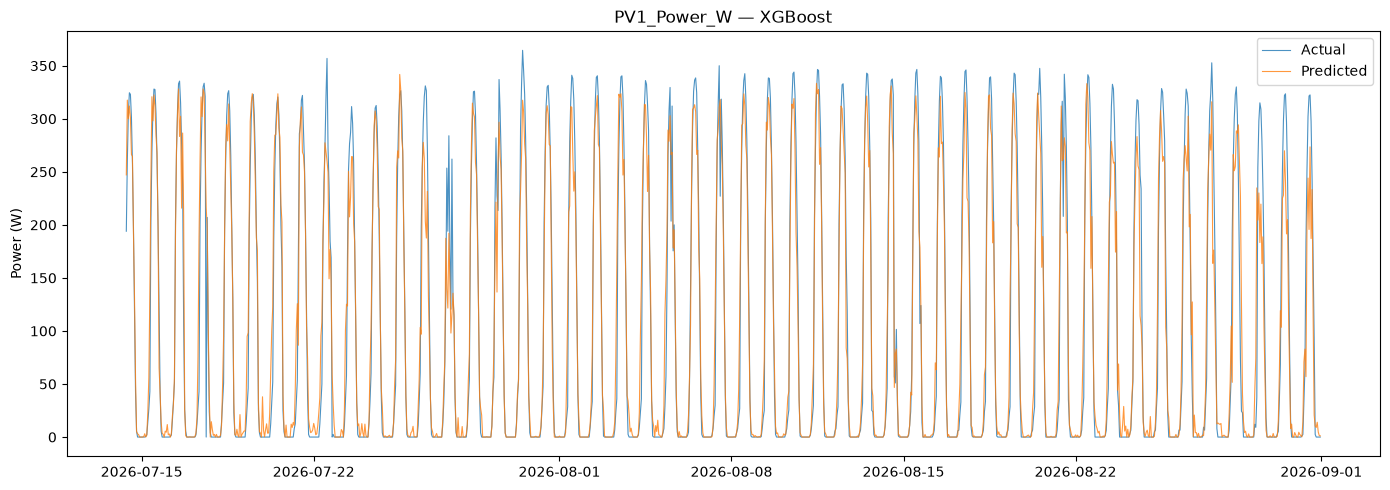

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_df["Timestamp"], y_test.values, label="Actual", linewidth=0.8, alpha=0.8)
ax.plot(test_df["Timestamp"], pred, label="Predicted", linewidth=0.8, alpha=0.8)
ax.set_ylabel("Power (W)")
ax.set_title(f"{TARGET} — XGBoost")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Residuals

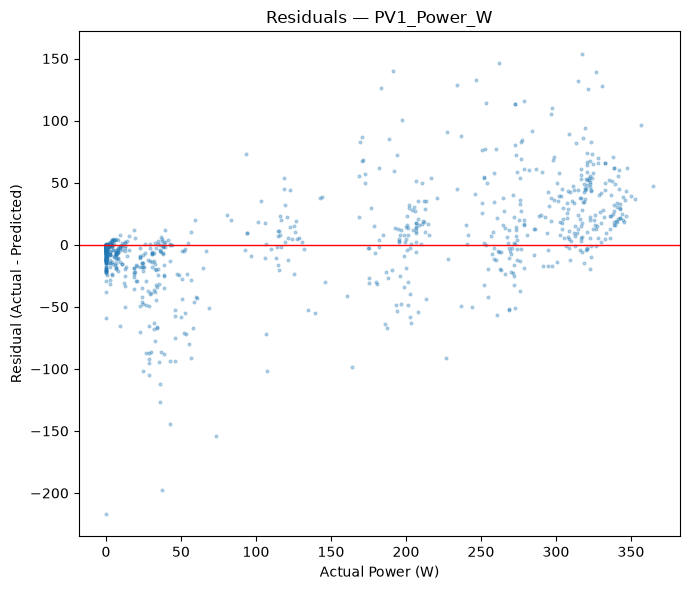

In [21]:
residuals = y_test.values - pred
plt.figure(figsize=(7, 6))
plt.scatter(y_test.values, residuals, s=4, alpha=0.3)
plt.axhline(0, color="red", linewidth=1)
plt.xlabel("Actual Power (W)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residuals — {TARGET}")
plt.tight_layout()
plt.show()


## 7. Feature importance

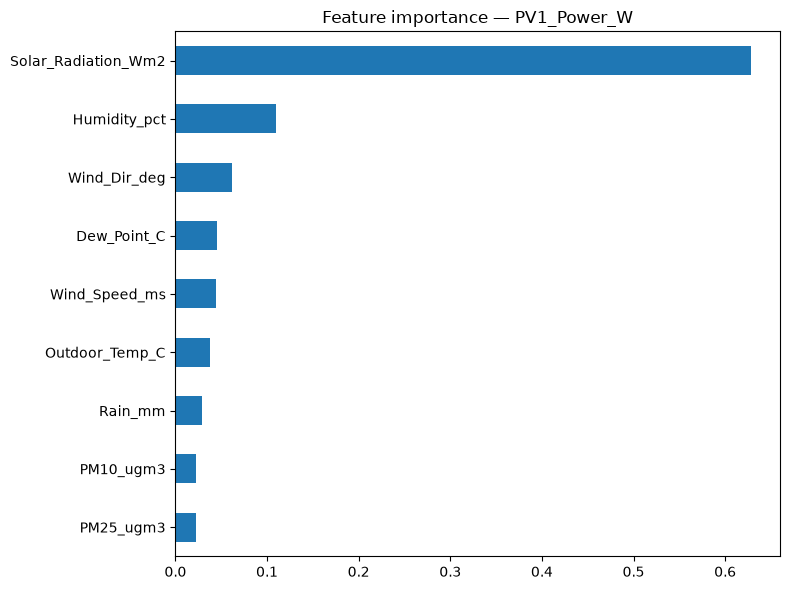

Solar_Radiation_Wm2    0.628441
Humidity_pct           0.110269
Wind_Dir_deg           0.061240
Dew_Point_C            0.045076
Wind_Speed_ms          0.044429
Outdoor_Temp_C         0.037308
Rain_mm                0.028951
PM10_ugm3              0.022227
PM25_ugm3              0.022059
dtype: float32

In [22]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title(f"Feature importance — {TARGET}")
plt.tight_layout()
plt.show()

importances


## 8. Save the model

In [24]:
import joblib
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(model, f"{OUTPUT_DIR}/xgb_{TARGET}_1.joblib")
joblib.dump(feature_cols, f"{OUTPUT_DIR}/feature_cols_1.joblib")
print(f"Saved model for target '{TARGET}' to {OUTPUT_DIR}")


Saved model for target 'PV1_Power_W' to ../Output


## Summary

- XGBoost trained on `PV1_Power_W`, using only weather/time features (no electrical readings,
  which would leak the answer).
- Evaluated on a chronological holdout (last ~20% of the timeline), full test set and
  daylight-only.
- Model and feature list saved to `Output/` for later use.

**Next steps:** hyperparameter tuning (`RandomizedSearchCV` with `TimeSeriesSplit`), and
re-evaluating once more months of data are available to cover the missing autumn/winter seasons.
